This notebook provides an example to generate a TRISO cylindrical compact placed in an hexagonal graphite matrix.  The data provided does not match the geometry of the project so this should be used as a guide only.

In [1]:
%matplotlib inline
import openmc
import openmc.deplete
import matplotlib.pyplot as plt
import glob
import shutil
import os
import sys
import openmc.examples
import numpy as np
import matplotlib.pyplot as plt
print('Done')

Done


In [2]:
openmc.config['cross_sections'] = '/home/ralitsam/endfb-vii.1-hdf5/cross_sections.xml'
output_dir = '/home/ralitsam/211Project/Problems/Sam_Problem3_CorrectMaterials'

In [3]:
fuel = openmc.Material(name='fuel')
fuel.add_nuclide('U238', 0.7502, 'wo')
fuel.add_nuclide('U235', 0.1376, 'wo')
fuel.add_nuclide('O16', 0.0897, 'wo')
fuel.add_nuclide('C0', 0.0224, 'wo')
fuel.set_density('g/cc', 10.5)

buff = openmc.Material(name='Buffer')
buff.add_nuclide('C0', 1.0, 'wo')
buff.set_density('g/cm3', 1.0)

iPyC = openmc.Material(name='iPyC')
iPyC.add_nuclide('C0', 1.0, 'wo')
iPyC.set_density('g/cm3', 1.9)

oPyC = openmc.Material(name='oPyC')
oPyC.add_nuclide('C0', 1.0, 'wo')
oPyC.set_density('g/cm3', 1.9)

SiC = openmc.Material(name='SiC')
SiC.add_nuclide('C0', 0.5, 'wo')
SiC.add_element('Si', 0.5, 'wo')
SiC.set_density('g/cm3', 3.2)

coolant = openmc.Material(name='coolant')
#NaFZrF4
coolant.add_nuclide('F19',0.4537, 'wo')
coolant.add_nuclide('Na23',0.1475, 'wo')
coolant.add_nuclide('Zr91',0.3988, 'wo')
coolant.set_density('g/cm3',2.96)
print('Done')

Done


In [4]:
graphite = openmc.Material(name='moderator')
graphite.add_nuclide('C0',  0.99998985, 'wo')
graphite.add_nuclide('B10', 0.00000015, 'wo')
graphite.add_nuclide('N14', 0.00001, 'wo')
graphite.set_density('g/cc', 1.65)

In [5]:
materials_file = openmc.Materials([fuel, graphite, buff, iPyC, oPyC, SiC,coolant])
materials_file.export_to_xml()

In [6]:
# Geometry definitions
fuel_radius = openmc.ZCylinder(surface_id=1, r=0.635)
coolant_radius = openmc.ZCylinder(surface_id=2, r=0.35)

compact_radius = openmc.ZCylinder(surface_id=6, r=0.635)

fuel_region = -fuel_radius
moder_fuel = +fuel_radius
coolant_region = -coolant_radius 
moder_coolant = +coolant_radius 

top_compact = openmc.ZPlane(surface_id=7, z0=+0.999)
bottom_compact = openmc.ZPlane(surface_id=8, z0=-0.999)

region = -compact_radius & -top_compact & +bottom_compact

# This block defines a fuel radius and a slightly smaller compact radius to avoid situations where TRISOs would be cut by the boundary.

top = openmc.ZPlane(surface_id=4, z0=+1, boundary_type='periodic')
bottom = openmc.ZPlane(surface_id=5, z0=-1, boundary_type='periodic')

fuel_cell = openmc.Cell(cell_id=1, fill=fuel, region=fuel_region)
moder_fuel_cell = openmc.Cell(cell_id=2, fill=graphite, region=moder_fuel)
graphite_cell = openmc.Cell(cell_id=3, fill=graphite)

coolant_cell = openmc.Cell(cell_id=4, fill=coolant, region=coolant_region)
moder_coolant_cell = openmc.Cell(cell_id=5, fill=graphite, region=moder_coolant)

fuel_u = openmc.Universe(universe_id=1001, cells=(fuel_cell,moder_fuel_cell))
graphite_u = openmc.Universe(universe_id=1002, cells=[graphite_cell])
coolant_u = openmc.Universe(universe_id=1005, cells=[coolant_cell,moder_coolant_cell])

inner = [coolant_u]
outer = [coolant_u,fuel_u,coolant_u,fuel_u,coolant_u,fuel_u]

#An hexagonal lattice is defined with a fuel universe surrounded by a graphite universe.
hex_lat = openmc.HexLattice(lattice_id=1003, name='assembly')

hex_lat.center = (0., 0.)
hex_lat.pitch = (1.8796,)
hex_lat.orientation = 'x'
hex_lat.outer = graphite_u
hex_lat.universes = [outer, inner]

# Create the prism that will contain the lattice
outer_surface = openmc.model.hexagonal_prism(edge_length=2.8194, orientation='x', boundary_type='periodic')


# Fill a cell with the lattice. This cell is filled with the lattice and contained within the prism.
main_assembly = openmc.Cell(cell_id=7000, fill=hex_lat, region=outer_surface & -top & +bottom)

/home/ralitsam/.conda/envs/openmc-env/lib/python3.12/site-packages/openmc/model/funcs.py:124: FutureWarning: The hexagonal_prism(...) function has been replaced by the HexagonalPrism(...) class. Future versions of OpenMC will not accept hexagonal_prism.
  warn("The hexagonal_prism(...) function has been replaced by the "


FLERP:  1100 0.55
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 ###

/home/ralitsam/.conda/envs/openmc-env/lib/python3.12/site-packages/openmc/model/triso.py:1188: UserWarning: Close random pack converged before reaching true sphere radius; some spheres may overlap. Try reducing contraction rate or packing fraction.
  warnings.warn('Close random pack converged before reaching true '
/home/ralitsam/.conda/envs/openmc-env/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another UniverseBase instance already exists with id=0.
  warn(msg, IDWarning)


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

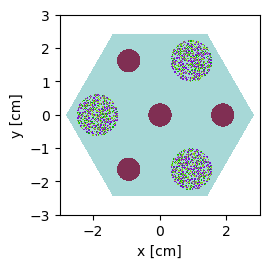

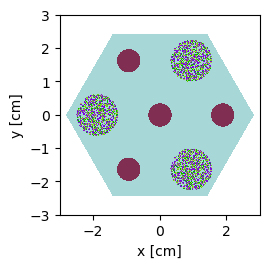

In [7]:
sensitivity_temps = [1100]
sensitivity_pfs = [0.55, 0.63]

for temp in sensitivity_temps:
    for packing_fraction in sensitivity_pfs:
        fuel.temperature = temp
        buff.temperature = 900
        iPyC.temperature = 900
        oPyC.temperature = 900
        SiC.temperature = 900
        coolant.temperature = 900
        graphite.temperature = 900
        
        #This block creates a TRISO universe.
        
        # Create TRISO universe
        spheres = [openmc.Sphere(r=1e-4*r)
                   for r in [212.5, 312.5, 347.5, 382.5]]
        #spheres = [openmc.Sphere(r=r)
         #          for r in [0.02125, 0.03125, 0.03475, 0.03825]]
        cells = [openmc.Cell(fill=fuel, region=-spheres[0]),
                 openmc.Cell(fill=buff, region=+spheres[0] & -spheres[1]),
                 openmc.Cell(fill=iPyC, region=+spheres[1] & -spheres[2]),
                 openmc.Cell(fill=SiC, region=+spheres[2] & -spheres[3]),
                 openmc.Cell(fill=oPyC, region=+spheres[3])]
        triso_univ = openmc.Universe(cells=cells)
        
        # This block places spheres of a given size in a region with a user defined packing fraction.  As the packing fraction gets larger, the run time increases substantially.
        outer_radius = 422.5*1e-4
        #print(domain.volume)
        print("FLERP: ", temp, packing_fraction)
        centers = openmc.model.pack_spheres(radius=outer_radius, region=region, pf=packing_fraction)
        
        #This block assigns a triso universe to each sphere.
        
        trisos = [openmc.model.TRISO(outer_radius, triso_univ, center) for center in centers]
        
        #This block creates a lattice over the TRISO region for acceleration purposes.  A virtual mesh is added and a list of TRISOs in each mesh cell is calculated.  Thus, when in a given cell, the nearest neighbor search is limited to surfaces in the mesh.
        
        lower_left, upper_right = fuel_cell.region.bounding_box
        lower_left[2] = -1.0
        upper_right[2] = 1.0
        shape = (3, 3, 3)
        pitch = (upper_right - lower_left)/shape
        lattice = openmc.model.create_triso_lattice(
            trisos, lower_left, pitch, shape, graphite)
        
        fuel_cell.fill = lattice
        
        # Create a universe that contains both 
        root = openmc.Universe(cells=[main_assembly])
        
        root.plot(origin = (0,0,0), pixels=(200, 200), width = (6.,6.), color_by = 'material')
        
        geom = openmc.Geometry(root)
        geom.export_to_xml()
        
        # OpenMC simulation parameters
        
        lower_left = [-3, -3, -1]
        upper_right = [3, 3, 1]
        uniform_dist = openmc.stats.Box(lower_left, upper_right)
        src = openmc.IndependentSource(space=uniform_dist)#, constraints={'fissionable': True})
        
        settings = openmc.Settings()
        settings.source = src
        settings.batches = 100
        settings.inactive = 25
        settings.particles = 2000
        settings.temperature = {'method': 'interpolation','range':(293.15,1923.15)}
        
        settings.export_to_xml()
        
        model = openmc.examples.pwr_pin_cell()
        
        model.tallies
        
        # Create equal-lethargy energies to put in filter
        energies = np.logspace(np.log10(1e-5), np.log10(20.0e6), 501)
        e_filter = openmc.EnergyFilter(energies)
        
        # Create tally with energy filter
        tally = openmc.Tally()
        tally.filters = [e_filter]
        tally.scores = ['flux']
        
        # Set model tallies
        model.tallies = [tally]
        
        openmc.mgxs.GROUP_STRUCTURES.keys()
        
        model.tallies
        
        openmc.run()
        
        # fuel.volume = len(trisos)*4/3*3.1416*(212.5*1e-4)**3
        
        # # Create depletion "operator"
        # model = openmc.Model(geometry=geom, materials=materials_file, settings=settings)
        # op = openmc.deplete.CoupledOperator(model, "chain_casl_pwr.xml")
        
        # # Perform simulation using the predictor algorithm
        # time_steps = [1.0, 2.0, 10.0, 20.0, 30.0]  # days
        # power = 1000  
        # integrator = openmc.deplete.PredictorIntegrator(op, time_steps, power, timestep_units='d')
        # integrator.integrate()
        
        # # Define a label based on PF or other variable
        pf_label = f"{int(packing_fraction * 100):03d}"  # e.g., 35 for 0.35 PF
        temp_label = f"{int(temp):03d}"
        for f in glob.glob("statepoint.*.h5"):
            # Extract step number from filename, e.g., 'statepoint.2.h5' → '2'
            new_name_statepoint = f"statepoint_pf{pf_label}_temperature{temp_label}.h5"
            shutil.move(f, os.path.join(output_dir, new_name_statepoint))
        for f in glob.glob("summary.h5"):
            # Extract step number from filename, e.g., 'statepoint.2.h5' → '2'
            new_name_summary = f"summary_pf{pf_label}_temperature{temp_label}.h5"
            shutil.move(f, os.path.join(output_dir, new_name_summary))
        for f in glob.glob("tallies.out"):
            # Extract step number from filename, e.g., 'statepoint.2.h5' → '2'
            new_name_tallies = f"tallies_pf{pf_label}_temperature{temp_label}.out"
            shutil.move(f, os.path.join(output_dir, new_name_tallies))

In [8]:
print("YEET YEET SKRRT SKRRT")

YEET YEET SKRRT SKRRT
